In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.gridspec as gridspec

/var/folders/fc/c9rjh96153j0tjdc4dhkrcwc0000gn/T/ipykernel_8322/1105045143.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax2.boxplot(
/var/folders/fc/c9rjh96153j0tjdc4dhkrcwc0000gn/T/ipykernel_8322/1105045143.py:197: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(


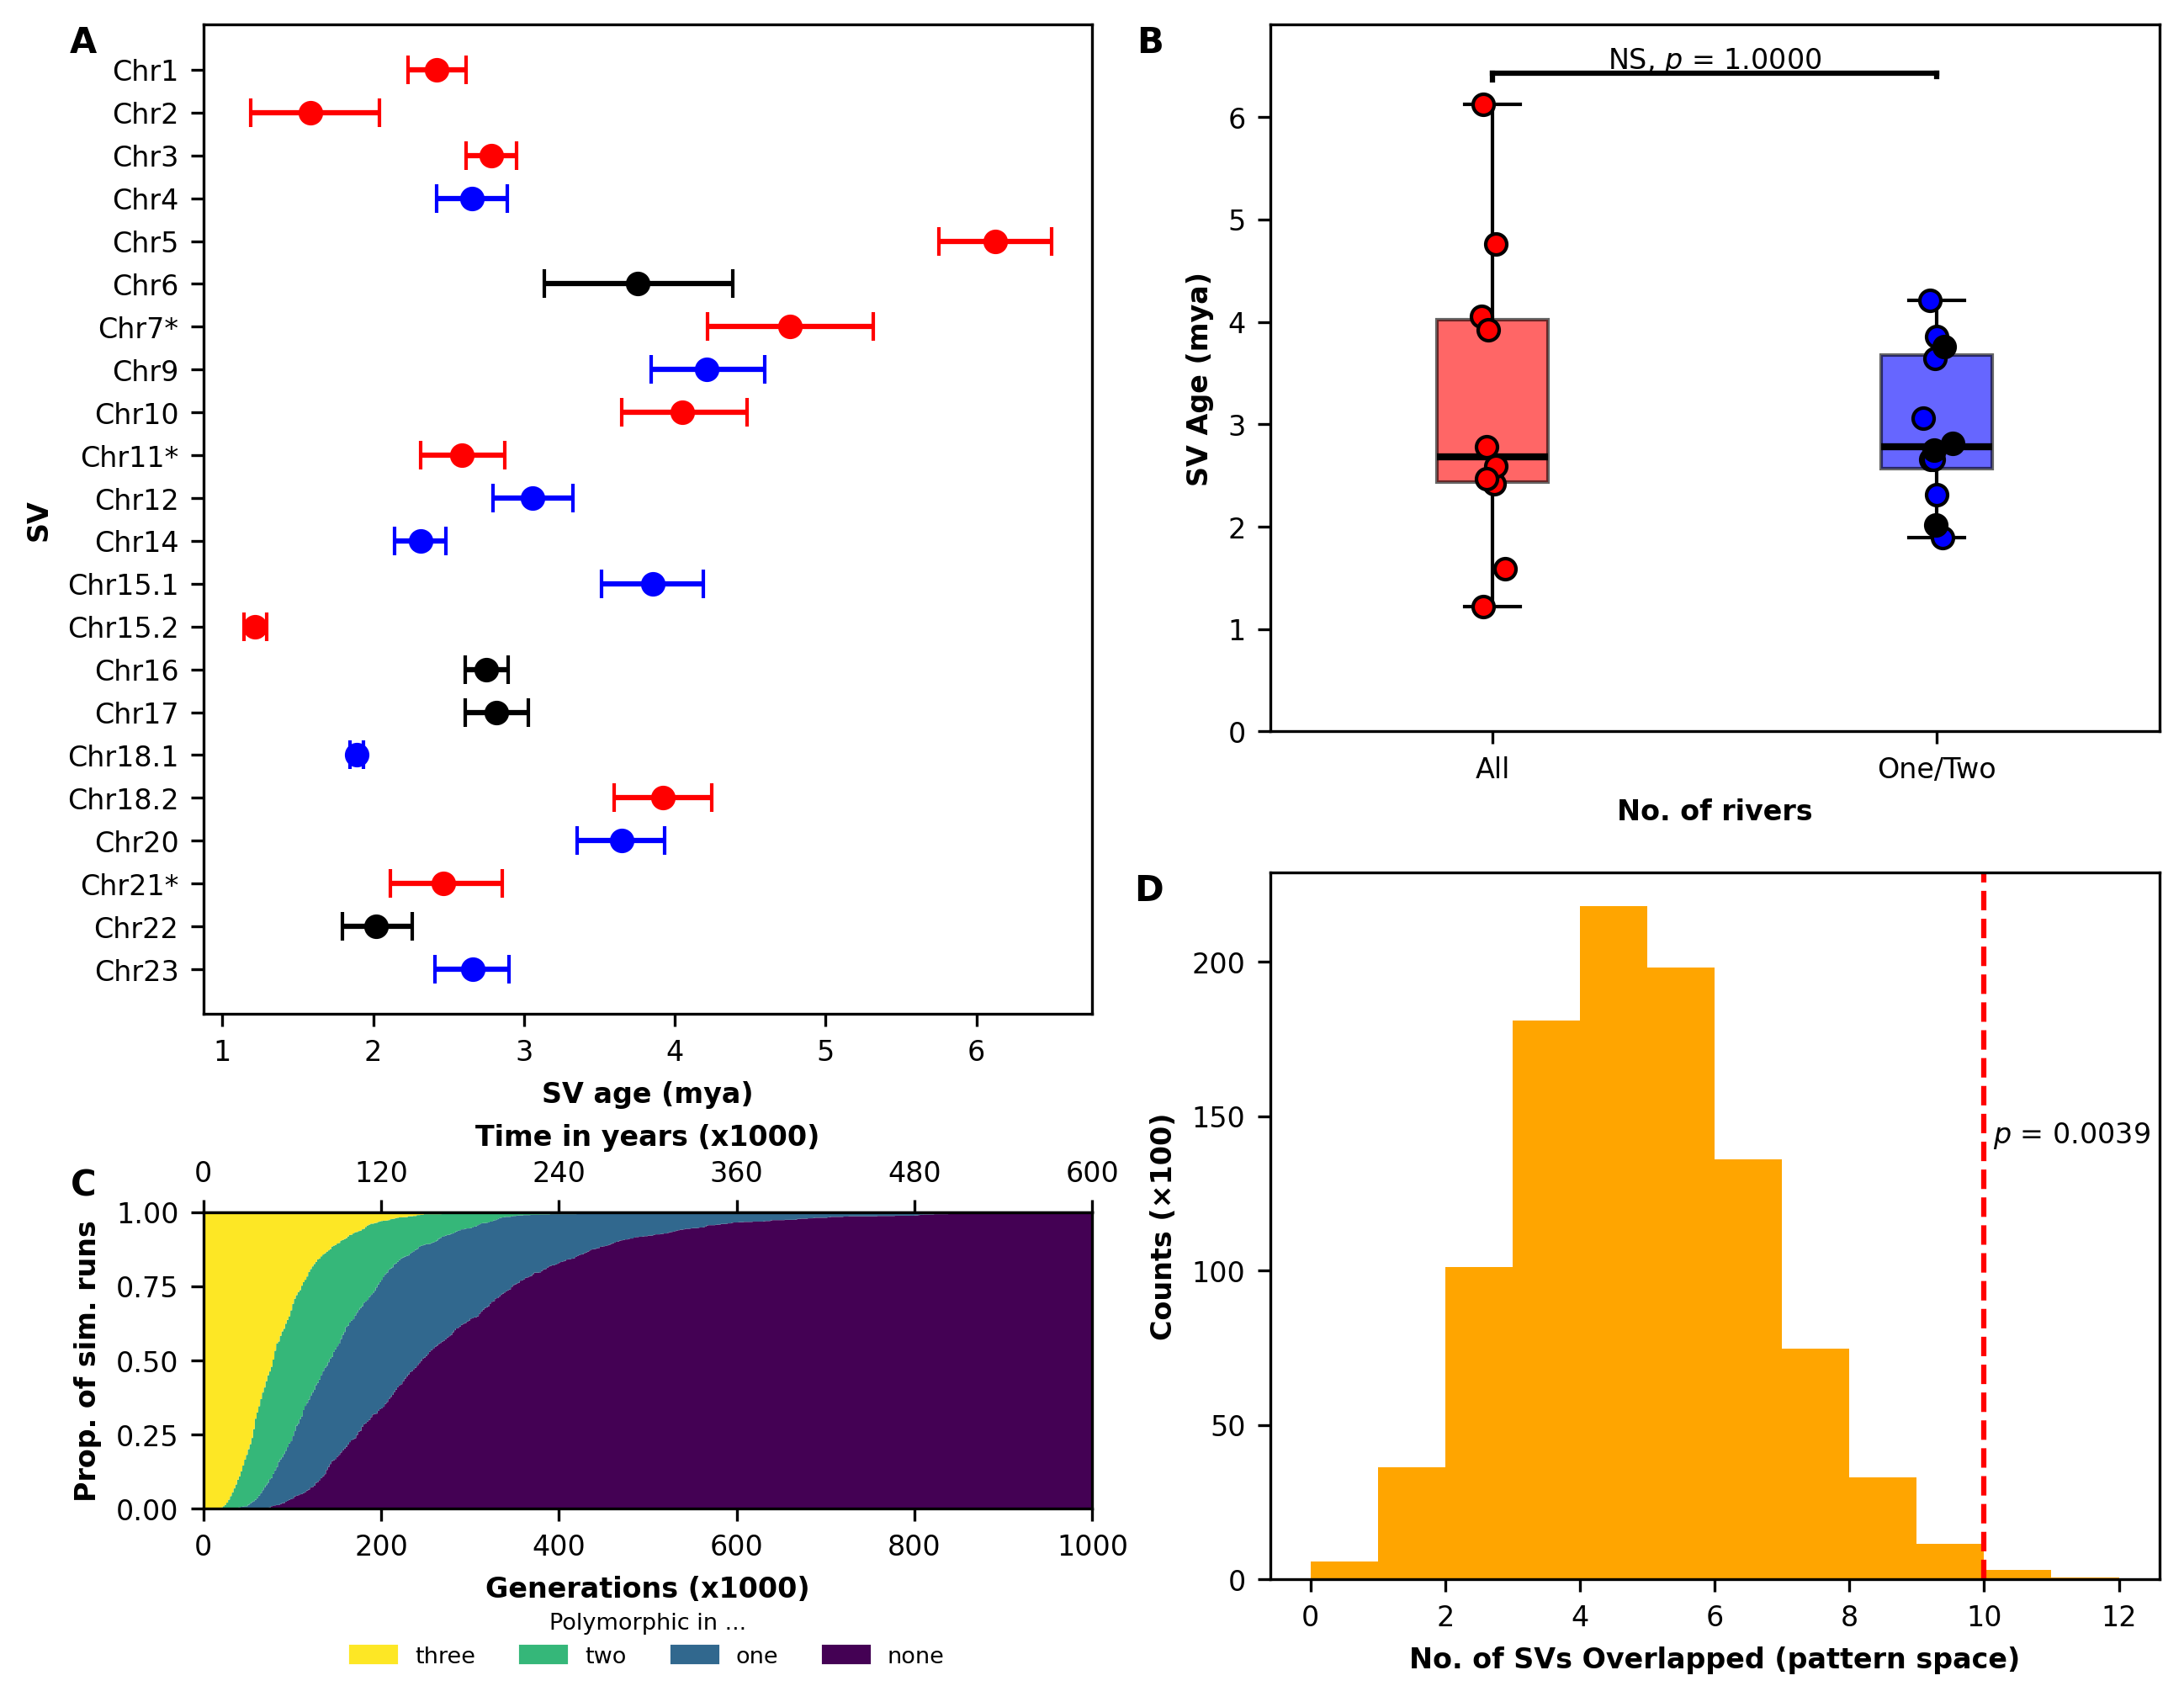

In [22]:


data_str = """SV\tRivers\tAge_avg\t95%_Lower\t95%_Upper
Chr1	all	2.4209	2.2298	2.6187
Chr2	all	1.5861	1.1894	2.0391
Chr3	all	2.7816	2.6154	2.9489
Chr4	A, Y	2.6538	2.4223	2.8893
Chr5	all	6.1243	5.7503	6.5009
Chr6	A	3.7538	3.1331	4.3856
Chr7*	all	4.7636	4.2144	5.3188
Chr9	A,Y	4.2128	3.8441	4.5958
Chr10	all	4.0498	3.6497	4.4771
Chr11*	all	2.5898	2.3125	2.8724
Chr12	Q,Y	3.0577	2.7956	3.3267
Chr14	A, Y	2.3143	2.1429	2.4815
Chr15.1	A, Y	3.8558	3.5135	4.1906
Chr15.2	all	1.217	1.141	1.2957
Chr16	Y	2.7492	2.6076	2.896
Chr17	Y	2.815	2.6081	3.0261
Chr18.1	Q,Y	1.8899	1.8487	1.9331
Chr18.2	all	3.9241	3.5958	4.2443
Chr20	Q,Y	3.6459	3.3524	3.933
Chr21*	all	2.4656	2.1147	2.8561
Chr22	Y	2.0204	1.7958	2.2608
Chr23	A, Y	2.6585	2.4115	2.9028
"""

# Read data
df = pd.read_csv(StringIO(data_str), sep="\t")
df.columns = df.columns.str.strip()

# Calculate CI widths
left_errors = df["Age_avg"] - df["95%_Lower"]
right_errors = df["95%_Upper"] - df["Age_avg"]

# Assign color groups
def assign_group(rivers):
    if rivers == "all":
        return 'red'
    elif len(rivers.split(",")) == 2:
        return 'blue'
    else:
        return 'black'

df['group_color'] = df['Rivers'].apply(assign_group)


# Highlight some SVs on y-axis if desired
# highlight = ['Chr7*', 'Chr11*', 'Chr15.2*', 'Chr21*']  # example
highlight = []

fig = plt.figure(figsize=(10, 8), dpi=300)

outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
left = outer[0].subgridspec(2, 1, height_ratios=[0.7, 0.3])

# RIGHT column → 2 rows (1 : 1)
right = outer[1].subgridspec(2, 1, height_ratios=[1, 1])

# Create axes
ax1 = fig.add_subplot(left[0])   # left top (70%)
ax3 = fig.add_subplot(left[1])   # left bottom (30%)

ax2 = fig.add_subplot(right[0])  # right top (50%)
ax4 = fig.add_subplot(right[1])  # right bottom (50%)

# --- Panel A: Original error bar plot ---
for idx, row in df.iterrows():
    color = row['group_color']
    ax1.errorbar(
        x=row["Age_avg"],
        y=idx,
        xerr=[[left_errors[idx]], [right_errors[idx]]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=4
    )

ax1.set_yticks(range(len(df["SV"])))
ax1.set_yticklabels(df["SV"],fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel("SV age (mya)", fontsize=8, fontweight="bold")
ax1.set_ylabel("SV", fontsize=8, fontweight="bold")

# Color and bold y-axis labels for highlights
for tick_label in ax1.get_yticklabels():
    if tick_label.get_text() in highlight:
        tick_label.set_fontweight('bold') 
        tick_label.set_color('black')      
    else:
        tick_label.set_fontweight('normal') 
        tick_label.set_color('black')       



# Panel B: Boxplot of the three groups ---
data_to_plot = [
    df[df['group_color'] == 'red']['Age_avg'],               # All rivers
    df[df['group_color'].isin(['blue', 'black'])]['Age_avg'] # One or two rivers
]


colors = ['red', 'blue', 'black']
labels = ['All', 'One/Two']

# --- Panel B: Boxplot of the three groups ---
box = ax2.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=labels,
    widths=0.25,  # <-- makes boxes wider (default is 0.5)
    medianprops=dict(color='black', linewidth=2)
)


# Color boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points with narrow jitter
# Box 1: red (all rivers)
y_red = df[df['group_color'] == 'red']['Age_avg']
x_red = np.random.normal(1, 0.02, size=len(y_red))  # box 1 = x=1
ax2.scatter(x_red, y_red, color='red', edgecolor='black', zorder=3)

# Box 2: blue + black (one/two rivers combined)
# plot blue and black separately, same x-position (box 2 = x=2)
y_blue = df[df['group_color'] == 'blue']['Age_avg']
x_blue = np.random.normal(2, 0.02, size=len(y_blue))
ax2.scatter(x_blue, y_blue, color='blue', edgecolor='black', zorder=3)

y_black = df[df['group_color'] == 'black']['Age_avg']
x_black = np.random.normal(2, 0.02, size=len(y_black))
ax2.scatter(x_black, y_black, color='black', edgecolor='black', zorder=3)


ax2.set_ylim(0,6.9)
ax2.set_ylabel("SV Age (mya)", fontsize=8, fontweight="bold")
ax2.set_xlabel("No. of rivers", fontsize=8, fontweight="bold")


# Coordinates for the bar
x_start = 1        
x_end = 2           
y = max(df['Age_avg']) + 0.3  
bar_height = 0.03  

# Draw horizontal line connecting the two boxes
ax2.plot([x_start, x_end], [y, y], color='black', linewidth=1.5)

# Draw small vertical caps at ends
ax2.plot([x_start, x_start], [y, y-bar_height*2], color='black', linewidth=1.5)
ax2.plot([x_end, x_end], [y, y-bar_height], color='black', linewidth=1.5)

# Add p-value text above the bar
p_value = 1
ax2.text((x_start + x_end)/2, y + 0.05, f"NS, $\\it{{p}}$ = {p_value:.4f}",
         ha='center', fontsize=8)

########### Panel C ############

# read data
df = pd.read_csv("./simulation_results_as_proportions_k20.csv")

# order categories (bottom → top stacking order)
order = ["none", "one", "two", "three"]
df["polymorphic_in"] = pd.Categorical(
    df["polymorphic_in"],
    categories=order,
    ordered=True
)

# colors (bottom → top)
colors = {
    "none":  "#440154",
    "one":   "#31688E",
    "two":   "#35B779",
    "three": "#FDE725",
}

# subset (only k20)
subset = df[df["k"] == "k20"]

# pivot to wide format
pivot = subset.pivot_table(
    index="generation",
    columns="polymorphic_in",
    values="frac",
    fill_value=0
)

# ensure correct column order
pivot = pivot[order]

# convert generation to thousands
x = pivot.index / 1000

# stacked area plot
ax3.stackplot(
    x,
    pivot.T,
    colors=[colors[c] for c in order]
)
ax3.margins(x=0)
# Bottom axis
ax3.set_xlabel("Generations (x1000)", fontsize=8, fontweight="bold")
ax3.set_ylabel("Prop. of sim. runs", fontsize=8, fontweight="bold")
ax3.margins(y=0)  
ax3.set_xlim(0, 1000) 
ax3.set_xticks([0, 200, 400, 600, 800, 1000])
ax3.set_xticklabels([0, 200, 400, 600, 800, 1000])

# Top axis (same scale)
secax = ax3.secondary_xaxis('top')

# get bottom tick positions
bottom_ticks = ax3.get_xticks()

# set same positions on top
secax.set_xticks(bottom_ticks)

# scale labels
secax.set_xticklabels([f"{t * 0.6:g}" for t in bottom_ticks])

# label + styling
secax.set_xlabel("Time in years (x1000)", fontsize=8, fontweight="bold")
secax.tick_params(axis='x', labelsize=8)

# Get current GridSpec cell bbox for ax3
ax3_pos = ax3.get_subplotspec().get_position(fig)  # full bbox of GridSpec cell

# Shrink height to 85%, keeping top fixed
new_height = ax3_pos.height * 0.7
ax3.set_position([ax3_pos.x0, ax3_pos.y0+0.035, ax3_pos.width, new_height])

# Place legend below axes (outside the plot)
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[c]) for c in reversed(order)]
labels = ["three", "two", "one", "none"]

ax3.legend(
    handles,
    labels,
    title="Polymorphic in ...",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),  # shift legend below axes
    ncol=4,
    frameon=False,
    fontsize=6.5,
    title_fontsize=6.5
)


######### panel D ############## 
df_D = pd.read_csv("~/3.SV/4.localPCA/female_genome/permutaion/space_noLG12_perm_results.txt", sep=r"\s+", header=None)
df_D.columns = ["results"]


O_B = 10
p_B = 0.0039



# Panel B
ax4.hist(df_D["results"], bins=range(0, 13), color='orange', alpha=1)
ax4.axvline(O_B, linestyle="--", color="red")
# axes[1].set_title("Panel B")
ax4.set_xlabel("No. of SVs Overlapped (pattern space)", fontsize=8, fontweight="bold")
from matplotlib.ticker import FuncFormatter


ax4.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/100:.0f}"))
ax4.set_ylabel("Counts (×100)", fontsize=8, fontweight="bold")

ax4.text(
    0.99, 0.65, f"$\\it{{p}}$ = {p_B:.4f}",
    transform=ax4.transAxes,
    ha="right", va="top", fontsize=8
)

# axes[1].set_xlim(0,17)
xticks = list(range(0, 13, 2))
ax4.set_xticks(xticks)



ax1.tick_params(axis='both', labelsize=8)
ax2.tick_params(axis='both', labelsize=8)
ax3.tick_params(axis='both', labelsize=8)
ax4.tick_params(axis='both', labelsize=8)
# plt.tight_layout()

ax1.text(-0.12, 1.00, "A", transform=ax1.transAxes,
         fontsize=10, fontweight="bold", va='top', ha='right')
ax2.text(-0.12, 1.00, "B", transform=ax2.transAxes,
         fontsize=10, fontweight="bold", va='top', ha='right')
# panel label (like your "C")
ax3.text(-0.12, 1.15, "C",
        transform=ax3.transAxes,
        fontsize=10, fontweight="bold",
        va='top', ha='right')
ax4.text(-0.12, 1.00, "D", transform=ax4.transAxes,
    fontsize=10, fontweight="bold", va="top", ha='right'
)

plt.savefig("Figure4.pdf", format="pdf",
            bbox_inches='tight',
            dpi=200)
plt.show()

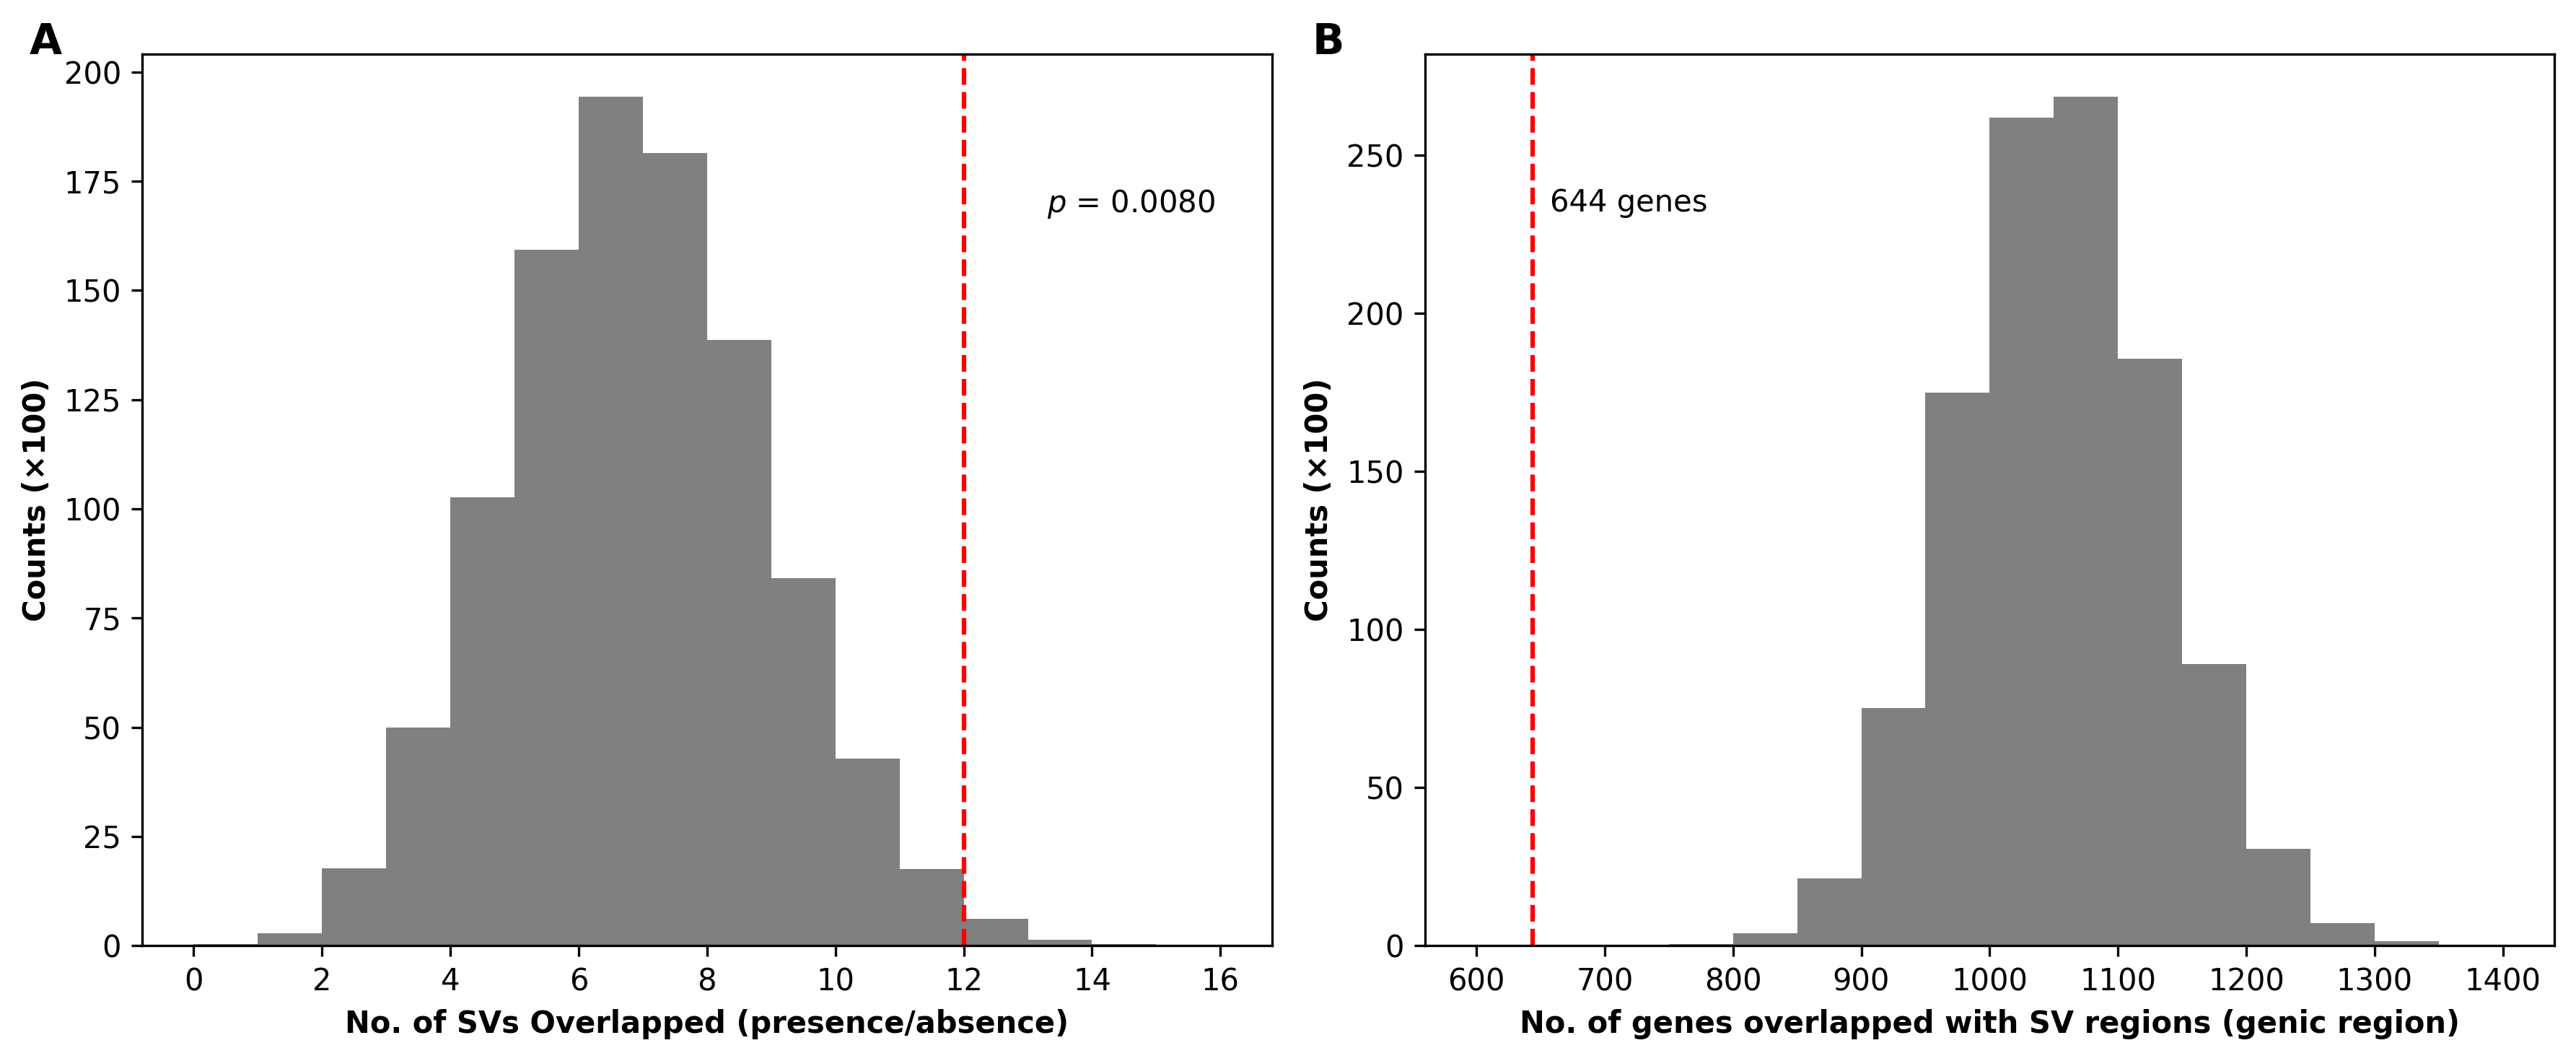

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# -----------------------------
# LOAD DATA
# -----------------------------
df_A = pd.read_csv(
    "~/3.SV/4.localPCA/female_genome/permutaion/color_noLG12_perm_results.txt",
    sep=r"\s+",
    header=None
)
df_A.columns = ["results"]

df_B = pd.read_csv(
    "~/3.SV/4.localPCA/female_genome/permutaion/genes_perm_counts.txt",
    sep=r"\s+",
    header=None
)
df_B.columns = ["results"]

# Observed values and p-values
O_A, p_A = 12, 0.00799
O_B = 644

#  figure set up
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# panel A
ax = axes[0]

ax.hist(
    df_A["results"],
    bins=range(0, 17),
    color="grey"
)

ax.axvline(x=O_A, linestyle="--", color="red", linewidth=1.5)

ax.set_xlabel("No. of SVs Overlapped (presence/absence)", fontsize=10, fontweight="bold")
ax.set_ylabel("Counts (×100)", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/100:.0f}"))
ax.set_xticks(range(0, 17, 2))

# p-value
ax.text(
    0.95, 0.85,
    f"$\\it{{p}}$ = {p_A:.4f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

# Panel label
ax.text(-0.1, 1.00, "A", transform=ax.transAxes,
        fontsize=14, fontweight="bold")


# panel B
ax = axes[1]

ax.hist(
    df_B["results"],
    bins=np.arange(600, 1450, 50),
    color="grey"
)

ax.axvline(x=O_B, linestyle="--", color="red", linewidth=1.5)

ax.set_xlabel("No. of genes overlapped with SV regions (genic region)", fontsize=10, fontweight="bold")
ax.set_ylabel("Counts (×100)", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/100:.0f}"))


ax.text(
    0.25, 0.85,
    "644 genes",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

# Panel label
ax.text(-0.1, 1.00, "B", transform=ax.transAxes,
        fontsize=14, fontweight="bold")


# plot
plt.tight_layout()
plt.savefig("./Figure_AB.png", dpi=300)
plt.show()